<a href="https://colab.research.google.com/github/Alone1011/ImageProcessing/blob/main/Pertemuan_4/2311532011_RifkiYuliandra_PengolahanCitra_imageBrightening_IP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# FUNGSI-FUNGSI DASAR

## a. Hitung Histogram

In [5]:
def hitung_histogram(citra):
    """Menghitung histogram citra secara manual."""
    hist = np.zeros(256, dtype=int)
    # Meratakan array 2D menjadi 1D untuk mempermudah iterasi
    citra_flat = citra.flatten()
    for piksel in citra_flat:
        hist[piksel] += 1
    return hist

Fungsi ini menggantikan cv2.calcHist. Fungsi ini membuat array kosong berukuran 256 (mewakili intensitas 0-255). Algoritma akan melakukan looping pada setiap piksel di citra dan menambahkan nilai 1 pada indeks array yang sesuai dengan nilai intensitas piksel tersebut.

## b. Normalisasi Histogram

In [6]:
def normalisasi_histogram(citra):
    """
    Melakukan Contrast Stretching (Normalisasi)
    Rumus: I_out = (I_in - Min) / (Max - Min) * 255
    """
    min_val = np.min(citra)
    max_val = np.max(citra)

    # Menghindari pembagian dengan nol jika gambar satu warna
    if max_val == min_val:
        return citra.copy()

    citra_norm = ((citra - min_val) / (max_val - min_val)) * 255
    return citra_norm.astype(np.uint8)

Fungsi ini melakukan teknik Contrast Stretching. Kode mencari nilai intensitas minimum (min_val) dan maksimum (max_val) dari citra. Kemudian, setiap piksel dihitung ulang menggunakan rumus peregangan linier $I_{out} = \frac{I_{in} - Min}{Max - Min} \times 255$ agar nilai piksel membentang penuh dari 0 hingga 255.

## c. Ekualisasi Histogram

In [7]:
def ekualisasi_histogram(citra):
    """Melakukan ekualisasi histogram dari awal (scratch)."""
    hist = hitung_histogram(citra)

    # 1. Hitung PMF (Probability Mass Function)
    total_piksel = citra.shape[0] * citra.shape[1]
    pmf = hist / total_piksel

    # 2. Hitung CDF (Cumulative Distribution Function)
    cdf = np.zeros(256)
    cdf[0] = pmf[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pmf[i]

    # 3. Pemetaan (Mapping) ke nilai 0-255
    peta_transformasi = np.floor(cdf * 255).astype(np.uint8)

    # 4. Terapkan pemetaan ke citra
    citra_equalized = np.zeros_like(citra)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            nilai_asli = citra[i, j]
            citra_equalized[i, j] = peta_transformasi[nilai_asli]

    return citra_equalized

ekualisasi_histogram(citra): Merupakan inti tugas yang diminta tanpa library siap pakai.

1. Menghitung total piksel.
2. Mencari nilai PMF (peluang kemunculan setiap intensitas).
3. Melakukan iterasi untuk menjumlahkan PMF menjadi nilai kumulatif (CDF).
4. Membuat peta_transformasi dengan mengalikan CDF dengan 255.
5. Menyalin (mapping) nilai piksel lama ke nilai piksel baru berdasarkan peta transformasi tersebut secara manual menggunakan nested loop.

# PROGRAM UTAMA

In [9]:
# 1. Membaca citra (Pastikan Anda sudah mengupload 'citra_test.jpg' ke Colab)
# Gunakan cv2.IMREAD_GRAYSCALE untuk mempermudah pemrosesan 1 channel
image_path = 'citra_test.jpg' # Ganti dengan nama file Anda
citra_asli = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if citra_asli is None:
    print("Citra tidak ditemukan! Pastikan sudah di-upload dan namanya sesuai.")
else:
    # 2. Proses Normalisasi
    citra_normalisasi = normalisasi_histogram(citra_asli)

    # 3. Proses Ekualisasi SETELAH Normalisasi
    citra_ekualisasi = ekualisasi_histogram(citra_normalisasi)

    # Menghitung histogram untuk keperluan visualisasi
    hist_asli = hitung_histogram(citra_asli)
    hist_norm = hitung_histogram(citra_normalisasi)
    hist_eq = hitung_histogram(citra_ekualisasi)

Proses:
1. Membaca Citra (cv2.imread): Program dimulai dengan membaca file gambar menggunakan cv2.imread(). Terdapat parameter tambahan cv2.IMREAD_GRAYSCALE. Parameter ini sangat penting karena mengubah citra langsung menjadi format grayscale (derajat keabuan/1 channel). Operasi histogram dasar jauh lebih mudah dan standar dilakukan pada citra grayscale karena kita hanya perlu mengolah satu nilai intensitas (0-255) per piksel, bukan tiga nilai (RGB).

2. Validasi Citra (if citra_asli is None): Ini adalah langkah pencegahan (penanganan error). Jika file gambar belum di-upload ke Google Colab atau salah ketik nama, program akan memberikan peringatan alih-alih mengalami crash.

3. Proses Beruntun (Sesuai Urutan Tugas):
Di sinilah logika utama tugas dieksekusi:
    * Pertama, citra_normalisasi dihasilkan dengan memasukkan citra_asli ke dalam fungsi normalisasi_histogram().
    * Kedua, sesuai instruksi tugas nomor 3, citra_ekualisasi dihasilkan dengan memproses hasil dari tahap pertama (citra_normalisasi) menggunakan fungsi ekualisasi_histogram().

4. Menyiapkan Data Histogram (hitung_histogram): Sebelum masuk ke tahap visualisasi, program menghitung data distribusi piksel untuk ketiga kondisi citra (Asli, Normalisasi, Ekualisasi) menggunakan fungsi manual yang telah kita buat. Data ini diperlukan untuk menggambar grafik batang (histogram).

# VISUALISASI HASIL

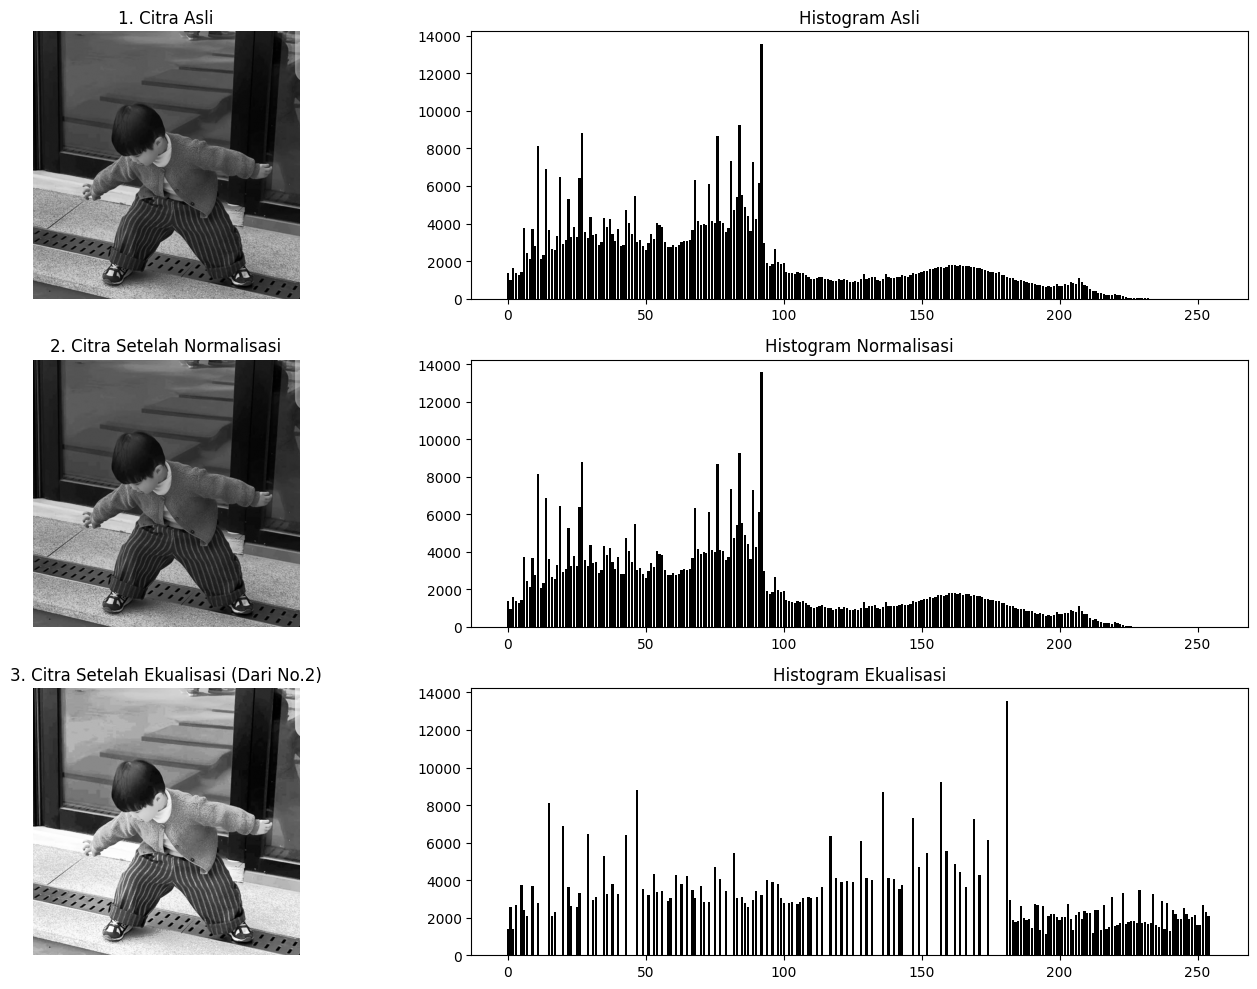

In [10]:
plt.figure(figsize=(15, 10))

# Baris 1: Citra Asli dan Histogramnya
plt.subplot(3, 2, 1)
plt.imshow(citra_asli, cmap='gray')
plt.title('1. Citra Asli')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.bar(range(256), hist_asli, color='black')
plt.title('Histogram Asli')

# Baris 2: Citra Normalisasi dan Histogramnya
plt.subplot(3, 2, 3)
plt.imshow(citra_normalisasi, cmap='gray')
plt.title('2. Citra Setelah Normalisasi')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.bar(range(256), hist_norm, color='black')
plt.title('Histogram Normalisasi')

# Baris 3: Citra Ekualisasi dan Histogramnya
plt.subplot(3, 2, 5)
plt.imshow(citra_ekualisasi, cmap='gray')
plt.title('3. Citra Setelah Ekualisasi (Dari No.2)')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.bar(range(256), hist_eq, color='black')
plt.title('Histogram Ekualisasi')

plt.tight_layout()
plt.show()